In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv('Sales.csv')
df2 = pd.read_csv('Motorcycles.csv')

In [5]:
df1.head()

,Sale_ID,Sale_Date,Customer_ID,Dealer_ID,Employee_ID,Bike_ID,Payment_Mode,Ex_Showroom_Price,Discount_Amount,On_Road_Price
0,SALE00001,2021-10-31,CUST00913,DLR190,EMP0569,BK002,UPI/Card,193080,0,218576
1,SALE00002,2020-03-22,CUST04468,DLR152,EMP0455,BK001,Cash,173500,0,196862
2,SALE00003,2021-03-14,CUST04598,DLR184,EMP0552,BK004,Finance,205900,0,234516
3,SALE00004,2023-07-09,CUST00054,DLR179,EMP0536,BK002,Finance,193080,0,221876
4,SALE00005,2020-07-09,CUST00760,DLR025,EMP0074,BK007,UPI/Card,206394,2000,234556


In [6]:
df2.head()

,Bike_ID,Model,Engine_CC,Category,Fuel_Type,Transmission,Mileage_kmpl,Fuel_Tank_L,Ex_Showroom_Price,Launch_Year
0,BK001,Bullet 350,349,Modern Classic,Petrol,5-Speed,37.0,13.0,173500,2023
1,BK002,Classic 350,349,Modern Classic,Petrol,5-Speed,36.2,13.0,193080,2021
2,BK003,Hunter 350,349,Roadster,Petrol,5-Speed,36.5,13.0,149900,2022
3,BK004,Meteor 350,349,Cruiser,Petrol,5-Speed,35.0,15.0,205900,2020
4,BK005,Himalayan 450,452,Adventure,Petrol,6-Speed,30.0,17.0,285000,2023


In [58]:
sales = pd.merge(df1,df2)

In [62]:
salesCount = sales.groupby('Model')['Sale_ID'].count()

In [63]:
salesCount

Model
Bullet 350            3599
Bullet 500             192
Classic 350           4402
Classic 500            216
Continental GT 535      87
Name: Sale_ID, dtype: int64

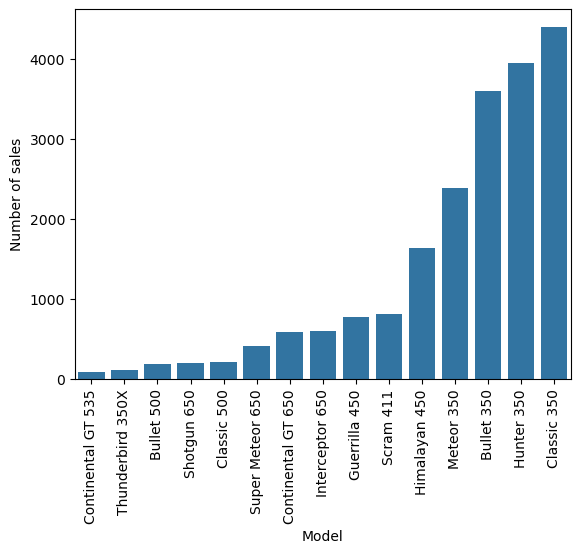

In [123]:
sns.barplot(salesCount.sort_values())
plt.ylabel("Number of sales")
plt.xticks(rotation=90);

<Axes: xlabel='On_Road_Price', ylabel='Count'>

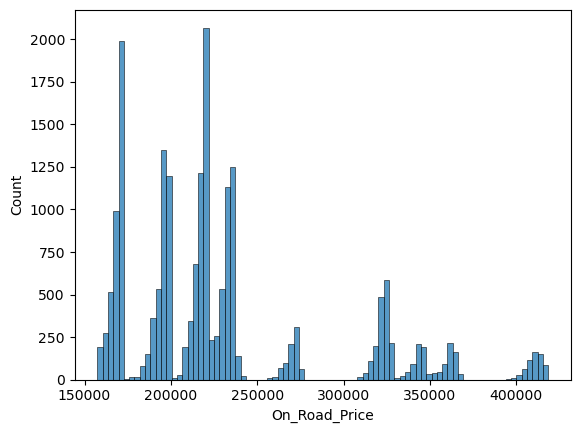

In [77]:
sns.histplot(df1['On_Road_Price'])

In [78]:
df3 = pd.read_csv("Customers.csv")

In [79]:
df3.head()

,Customer_ID,Customer_Name,Age,Age_Group,Gender,Occupation,Annual_Income,Marital_Status,State,City,Customer_Segment,Registration_Date
0,CUST00001,Manoj Iyer,28,26-35,Male,IT Professional,688066,Married,Punjab,Jalandhar,Touring / Adventure,2021-09-26
1,CUST00002,Deepak Rao,33,26-35,Male,Student,549114,Married,Karnataka,Bengaluru,Daily Commuter,2021-09-22
2,CUST00003,Dev Kumar,41,36-45,Male,Engineer,904677,Married,Uttar Pradesh,Varanasi,Daily Commuter,2021-07-05
3,CUST00004,Amit Das,25,18-25,Male,IT Professional,1329105,Single,Andhra Pradesh,Guntur,First-time Buyer,2026-03-21
4,CUST00005,Karthik Chowdhury,22,18-25,Male,Government Employee,1244911,Single,Tamil Nadu,Chennai,Daily Commuter,2024-01-31


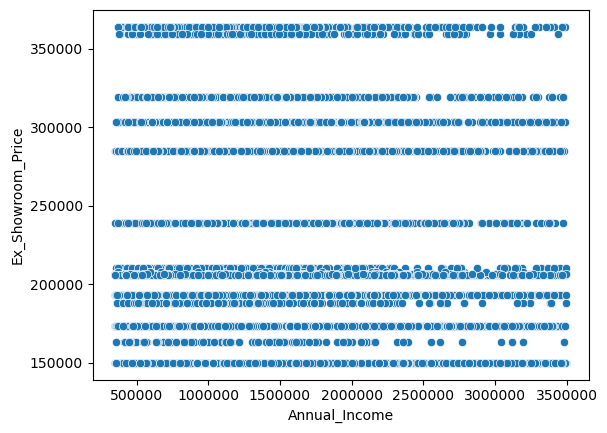

In [124]:
CusSales = pd.merge(df1,df3, on="Customer_ID")
sns.scatterplot(CusSales, x='Annual_Income', y='Ex_Showroom_Price')
plt.ticklabel_format(style='plain', axis='x')

<Axes: xlabel='Ex_Showroom_Price', ylabel='Count'>

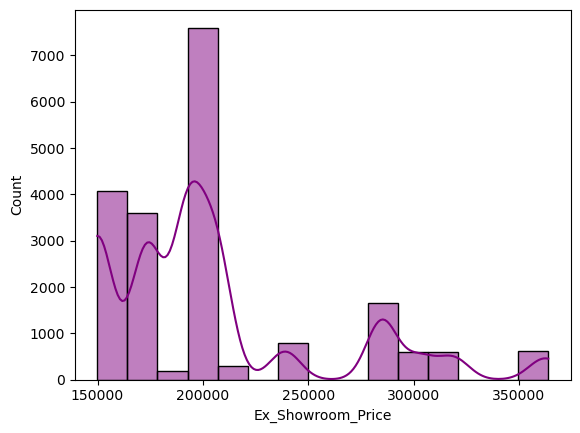

In [90]:
sns.histplot(data=sales, x='Ex_Showroom_Price', bins=15, kde=True, color='purple')

In [117]:
mergedData = df1.merge(df2).merge(pd.read_csv("Dealers.csv"))

In [118]:
mergedData.head()

,Sale_ID,Sale_Date,Customer_ID,Dealer_ID,Employee_ID,Bike_ID,Payment_Mode,Ex_Showroom_Price,Discount_Amount,On_Road_Price,...,Fuel_Tank_L,Launch_Year,Dealer_Name,Dealer_Type,State,City,Region,Opening_Year,Sales_Target,Dealer_Rating
0,SALE00001,2021-10-31,CUST00913,DLR190,EMP0569,BK002,UPI/Card,193080,0,218576,...,13.0,2021,Gaya Automobiles Royal Enfield,Authorized Dealership,Bihar,Gaya,East,2018,92,4.6
1,SALE00002,2020-03-22,CUST04468,DLR152,EMP0455,BK001,Cash,173500,0,196862,...,13.0,2023,Royal Enfield Flagship Store - Pune,Flagship Showroom,Maharashtra,Pune,West,2009,158,4.4
2,SALE00003,2021-03-14,CUST04598,DLR184,EMP0552,BK004,Finance,205900,0,234516,...,15.0,2020,Coimbatore Motors Royal Enfield,Authorized Dealership,Tamil Nadu,Coimbatore,South,2019,127,4.5
3,SALE00004,2023-07-09,CUST00054,DLR179,EMP0536,BK002,Finance,193080,0,221876,...,13.0,2021,Thiruvananthapuram Speedways Royal Enfield,Studio Store,Kerala,Thiruvananthapuram,South,2018,51,3.7
4,SALE00005,2020-07-09,CUST00760,DLR025,EMP0074,BK007,UPI/Card,206394,2000,234556,...,15.0,2022,Royal Enfield Flagship Store - Madurai,Flagship Showroom,Tamil Nadu,Madurai,South,2014,180,4.2


<Axes: xlabel='Region', ylabel='Model'>

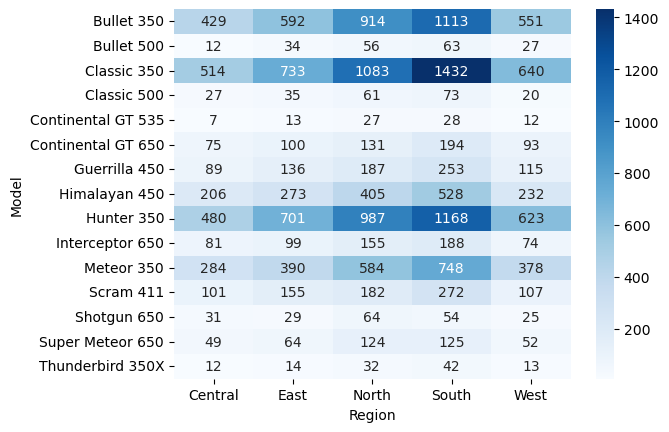

In [119]:
grid = pd.crosstab(mergedData['Model'], mergedData['Region'])
sns.heatmap(grid, annot=True, fmt='d', cmap='Blues')